In [ ]:
# =============================================================================
#  Fermi Velocity Prediction Pipeline  v2  — family + subfamily features
#  Input  : train_raw.csv, unique_m.csv, fermi_759.csv
#  Output : UCI_with_Fermi_Velocity.csv
#           (21,263 rows | 81 features + material + family + subfamily + Predicted_vF)
# =============================================================================

import pandas as pd
import numpy as np
import re
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

# =============================================================================
# STEP 1 — Load data
# =============================================================================
df_train    = pd.read_csv("train_raw.csv")
df_unique_m = pd.read_csv("unique_m.csv")
df_fermi    = pd.read_csv("fermi_759.csv")   # 759 rows | 169 unique materials
df_169      = pd.read_csv("Fermi_169_unique_v2.csv")

# # Keep ORIGINAL case for regex-based classification; lowercase only as merge key
# df_unique_m['material_lower'] = df_unique_m['material'].str.strip().str.lower()
# df_unique_m['material_orig']  = df_unique_m['material'].str.strip()
# df_fermi['material']          = df_fermi['material'].str.strip().str.lower()

# lookup: lowercase → original case
# orig_case_map = dict(zip(df_unique_m['material_lower'], df_unique_m['material_orig']))


In [2]:
"""
Feature selection pipeline for Fermi velocity (vF) prediction.

Pipeline:
  1. Load data, build numeric feature matrix X and log10(vF) target y.
  2. RobustScale the numeric features.
  3. Step A - Correlation pruning: drop one of each pair of features with
     |Spearman correlation| > 0.9, keeping the lower-redundancy member
     of each property group (prefer wtd_* variants).
  4. Step B - Fused consensus on the pruned set:
       - Mutual Information (regression) ranking
       - PLS-VIP (Variable Importance in Projection) ranking
     Take the union of each method's top-N features.
  5. Re-prune the union for any reintroduced |corr| > 0.9 pairs.
  6. Report the final feature list (~8-12 features), ready to combine
     with the 'family' categorical column for modeling.
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score

RANDOM_STATE = 42

# -----------------------------------------------------------------------
# 1. Load data
# -----------------------------------------------------------------------
DATA_PATH = "Fermi_169_unique_v2.csv"
df = pd.read_csv(DATA_PATH)

EXCLUDE_COLS = [
    "material", "critical_temp", "vF (m/s)", "family", "subfamily",
    "Method", "Reliability", "#", "Family", "Sub-family",
    "Tc (K)", "vF (eV\u00b7\u00c5)",
]
numeric_features = [c for c in df.columns if c not in EXCLUDE_COLS]
print(f"Starting numeric features: {len(numeric_features)}")

X = df[numeric_features].copy()
y = np.log10(df["vF (m/s)"].values)  # log-transformed target

# -----------------------------------------------------------------------
# 2. Scale
# -----------------------------------------------------------------------
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=numeric_features, index=X.index)

# -----------------------------------------------------------------------
# 3. Step A - correlation pruning (|Spearman| > 0.9)
# -----------------------------------------------------------------------
def prune_correlated(X_df, threshold=0.9, prefer_wtd=True):
    """
    Greedily drop one feature from each pair with |Spearman corr| > threshold.
    When choosing which to drop, prefer to KEEP the 'wtd_*' version
    (weighted-by-fraction features tend to carry more compositional info).
    """
    corr = X_df.corr(method="spearman").abs()
    cols = list(X_df.columns)
    to_drop = set()

    for i, c1 in enumerate(cols):
        if c1 in to_drop:
            continue
        for c2 in cols[i + 1:]:
            if c2 in to_drop:
                continue
            if corr.loc[c1, c2] > threshold:
                # decide which to drop
                c1_wtd = c1.startswith("wtd_")
                c2_wtd = c2.startswith("wtd_")
                if prefer_wtd and c1_wtd and not c2_wtd:
                    to_drop.add(c2)
                elif prefer_wtd and c2_wtd and not c1_wtd:
                    to_drop.add(c1)
                else:
                    # default: drop the second one encountered
                    to_drop.add(c2)

    kept = [c for c in cols if c not in to_drop]
    return kept, to_drop


pruned_features, dropped_features = prune_correlated(X_scaled, threshold=0.9)
print(f"\nStep A - correlation pruning (|Spearman| > 0.9)")
print(f"  Dropped {len(dropped_features)} redundant features")
print(f"  Remaining: {len(pruned_features)} features")

X_pruned = X_scaled[pruned_features]

# -----------------------------------------------------------------------
# 4. Step B - fused consensus: Mutual Information + PLS-VIP
# -----------------------------------------------------------------------

# --- 4a. Mutual Information ranking ---
mi_scores = mutual_info_regression(X_pruned, y, random_state=RANDOM_STATE)
mi_ranking = pd.Series(mi_scores, index=pruned_features).sort_values(ascending=False)

# --- 4b. PLS-VIP ranking ---
def compute_vip(pls_model, X_arr, y_arr):
    """
    Compute Variable Importance in Projection (VIP) scores for a fitted
    PLSRegression model.
    """
    t = pls_model.x_scores_      # (n_samples, n_components)
    w = pls_model.x_weights_     # (n_features, n_components)
    q = pls_model.y_loadings_    # (1, n_components) for single-output y

    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)  # SSY explained per component
    total_s = np.sum(s)

    vip = np.zeros((p,))
    for j in range(p):
        weight = np.array([
            (w[j, k] / np.linalg.norm(w[:, k])) ** 2 * s[k]
            for k in range(h)
        ])
        vip[j] = np.sqrt(p * np.sum(weight) / total_s)
    return vip


# choose number of PLS components via LOOCV on the pruned feature set
loo = LeaveOneOut()
max_components = min(10, len(pruned_features), X_pruned.shape[0] - 1)
cv_scores = []
for n_comp in range(1, max_components + 1):
    pls = PLSRegression(n_components=n_comp)
    scores = cross_val_score(pls, X_pruned, y, cv=loo, scoring="neg_mean_squared_error")
    cv_scores.append(scores.mean())

best_n_components = int(np.argmax(cv_scores)) + 1
print(f"\nStep B - PLS: best n_components by LOOCV = {best_n_components}")

pls_final = PLSRegression(n_components=best_n_components)
pls_final.fit(X_pruned, y)
vip_scores = compute_vip(pls_final, X_pruned.values, y)
vip_ranking = pd.Series(vip_scores, index=pruned_features).sort_values(ascending=False)

# -----------------------------------------------------------------------
# Union of top-N from each method
# -----------------------------------------------------------------------
TOP_N = 6  # top-N per method; union of two top-6 lists -> ~8-12 final features

top_mi = set(mi_ranking.head(TOP_N).index)
top_vip = set(vip_ranking.head(TOP_N).index)
union_features = list(top_mi | top_vip)
overlap_features = top_mi & top_vip

print(f"\nTop-{TOP_N} by Mutual Information:")
print(mi_ranking.head(TOP_N).round(4).to_string())

print(f"\nTop-{TOP_N} by PLS-VIP:")
print(vip_ranking.head(TOP_N).round(4).to_string())

print(f"\nOverlap (appear in both top-{TOP_N}): {len(overlap_features)}")
for f in sorted(overlap_features):
    print(f"  {f}")

print(f"\nUnion size before re-pruning: {len(union_features)}")

# -----------------------------------------------------------------------
# 5. Re-prune the union (in case the two methods picked correlated
#    representatives of the same property group)
# -----------------------------------------------------------------------
final_features, final_dropped = prune_correlated(X_scaled[union_features], threshold=0.9)

print(f"\nStep 5 - re-pruning union")
print(f"  Dropped (redundant within union): {len(final_dropped)} -> {sorted(final_dropped)}")
print(f"  Final feature count: {len(final_features)}")

# -----------------------------------------------------------------------
# 6. Final report
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("FINAL SELECTED NUMERIC FEATURES (combine with 'family' for modeling)")
print("=" * 60)
for f in final_features:
    mi_val = mi_ranking.get(f, np.nan)
    vip_val = vip_ranking.get(f, np.nan)
    flag = "MI+VIP" if f in overlap_features else ("MI" if f in top_mi else "VIP")
    print(f"  {f:35s}  MI={mi_val:.4f}  VIP={vip_val:.4f}  [{flag}]")

# save outputs for downstream modeling steps
pd.Series(final_features).to_csv("selected_features.csv", index=False, header=["feature"])
print("\nSaved final feature list -> selected_features.csv")


Starting numeric features: 81

Step A - correlation pruning (|Spearman| > 0.9)
  Dropped 31 redundant features
  Remaining: 50 features

Step B - PLS: best n_components by LOOCV = 9

Top-6 by Mutual Information:
wtd_mean_Valence               1.4318
wtd_mean_FusionHeat            1.4120
wtd_std_ThermalConductivity    1.3415
wtd_gmean_Density              1.3071
wtd_std_FusionHeat             1.2885
wtd_std_fie                    1.2565

Top-6 by PLS-VIP:
range_Valence                   1.5737
wtd_std_Valence                 1.5372
wtd_entropy_ElectronAffinity    1.4981
wtd_entropy_fie                 1.2880
wtd_entropy_FusionHeat          1.2667
mean_ElectronAffinity           1.2639

Overlap (appear in both top-6): 0

Union size before re-pruning: 12

Step 5 - re-pruning union
  Dropped (redundant within union): 0 -> []
  Final feature count: 12

FINAL SELECTED NUMERIC FEATURES (combine with 'family' for modeling)
  wtd_entropy_ElectronAffinity         MI=0.6892  VIP=1.4981  [VIP]
  w

In [3]:
"""
Fermi Velocity (vF) Prediction — XGBoost Regression + Snap Pipeline
=====================================================================
Dataset  : Fermi_169_unique_v2.csv  (n = 169)
Target   : vF (m/s) — log10-transformed for training
Features : 12 selected numeric + family one-hot (6 → 5 columns) = 17 total
Eval     : Leave-One-Out CV (LOOCV) — only unbiased option at n = 169

Approach : Regression + snap-to-nearest-valid-vF (best of both worlds)
  - Regression generalises well even for rare subfamilies (n=2-3)
    where a classifier collapses under LOOCV.
  - After prediction, every output is snapped to the nearest physically
    valid vF value (one of 17 canonical values from the training lookup).
  - This guarantees all predicted vF values are physically meaningful
    while retaining the stability advantage of regression.

Output   : trained model, predictions on 21,263-row UCI dataset, plots
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import joblib, json

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# =============================================================================
# 1. LOAD DATA
# =============================================================================
TRAIN_PATH = "Fermi_169_unique_v2.csv"
UCI_PATH   = "UCI_family_subFamily.csv"

df_train = pd.read_csv("Fermi_169_unique_v2.csv")
df_uci   = pd.read_csv("UCI_family_subFamily.csv")

print(f"Training set : {df_train.shape[0]} samples")
print(f"UCI set      : {df_uci.shape[0]} samples")
print(f"\nFamily distribution (training):")
print(df_train["family"].value_counts().to_string())


Training set : 169 samples
UCI set      : 21263 samples

Family distribution (training):
family
Cuprates                 82
Iron-based               35
Conventional / Alloys    30
Mg-B related              8
Heavy Fermion             8
Chalcogenide              6


In [4]:

# =============================================================================
# 2. vF LOOKUP TABLE  (subfamily -> vF in m/s)
#    Derived directly from the training data — NOT hardcoded — so it always
#    reflects whatever subfamily labels are actually present in the CSV.
# =============================================================================
vf_lookup = df_train.groupby("subfamily")["vF (m/s)"].first().to_dict()
VALID_VF  = np.array(sorted(set(vf_lookup.values())))
 
print(f"\n{len(vf_lookup)} subfamilies -> {len(VALID_VF)} unique valid vF values")
 
# Catch-all subfamily buckets where the chemistry-rule formula parser could
# NOT confidently resolve a specific subfamily. Rows in these buckets are
# the only ones routed to the ML fallback model.
AMBIGUOUS_SUBFAMILIES = {"other", "iron_other", "cuprate_other"}
 
def is_ambiguous_row(subfamily, low_confidence=False):
    """True if this row must go through the ML fallback instead of direct lookup."""
    return (subfamily in AMBIGUOUS_SUBFAMILIES) or bool(low_confidence)
 
# routing flags
df_train["is_ambiguous"] = df_train["subfamily"].apply(is_ambiguous_row)
df_uci["is_ambiguous"]   = df_uci.apply(
    lambda r: is_ambiguous_row(r["subfamily"], r["low_confidence"]), axis=1
)
 
print(f"\nTraining set routing:")
print(f"  Direct lookup (non-ambiguous) : {(~df_train['is_ambiguous']).sum()} rows "
      f"({(~df_train['is_ambiguous']).mean()*100:.1f}%)")
print(f"  ML fallback (ambiguous)       : {df_train['is_ambiguous'].sum()} rows "
      f"({df_train['is_ambiguous'].mean()*100:.1f}%)")
 
print(f"\nUCI set routing:")
print(f"  Direct lookup (non-ambiguous) : {(~df_uci['is_ambiguous']).sum():,} rows "
      f"({(~df_uci['is_ambiguous']).mean()*100:.2f}%)")
print(f"  ML fallback (ambiguous)       : {df_uci['is_ambiguous'].sum():,} rows "
      f"({df_uci['is_ambiguous'].mean()*100:.2f}%)")


22 subfamilies -> 17 unique valid vF values

Training set routing:
  Direct lookup (non-ambiguous) : 159 rows (94.1%)
  ML fallback (ambiguous)       : 10 rows (5.9%)

UCI set routing:
  Direct lookup (non-ambiguous) : 15,790 rows (74.26%)
  ML fallback (ambiguous)       : 5,473 rows (25.74%)


In [5]:

# =============================================================================
# 3. SAFETY-NET OVERRIDE for single-valued families
#    (kept as a defensive backstop inside the ML branch only — in the hybrid
#    design Chalcogenide/Mg-B rows are virtually always resolved via direct
#    lookup already, since their subfamily is never one of the ambiguous
#    catch-all buckets. This guards against any edge case.)
# =============================================================================
SINGLE_VALUE_FAMILIES = {
    "Chalcogenide": 95000,
    "Mg-B related": 560000,
}
 
def apply_family_override(pred_ms_array, family_array):
    pred_ms_array = np.asarray(pred_ms_array).copy()
    family_array  = np.asarray(family_array)
    for fam, val in SINGLE_VALUE_FAMILIES.items():
        pred_ms_array[family_array == fam] = val
    return pred_ms_array
 
def snap_to_valid(pred_ms_array):
    """Round each regression prediction to the nearest physically valid vF."""
    pred_ms_array = np.asarray(pred_ms_array).reshape(-1, 1)
    diffs = np.abs(pred_ms_array - VALID_VF)
    return VALID_VF[diffs.argmin(axis=1)]

In [6]:

# =============================================================================
# 4. FEATURE MATRIX  (used only for the ML fallback model)
# =============================================================================
NUMERIC_FEATURES = [
    "wtd_std_fie",
    "wtd_entropy_ElectronAffinity",
    "wtd_std_ThermalConductivity",
    "wtd_entropy_fie",
    "wtd_std_FusionHeat",
    "range_Valence",
    "mean_ElectronAffinity",
    "wtd_std_Valence",
    "wtd_mean_FusionHeat",
    "wtd_entropy_FusionHeat",
    "wtd_gmean_Density",
    "wtd_mean_Valence",
]
 
ohe       = OneHotEncoder(sparse_output=False, drop=None, handle_unknown="ignore")
fam_train = ohe.fit_transform(df_train[["family"]])
fam_uci   = ohe.transform(df_uci[["family"]])
fam_cols  = list(ohe.categories_[0])   # 6 columns, no prefix
 
X_train = np.hstack([df_train[NUMERIC_FEATURES].values, fam_train])
X_uci   = np.hstack([df_uci[NUMERIC_FEATURES].values,   fam_uci  ])
 
y_log         = np.log10(df_train["vF (m/s)"].values)
y_ms          = df_train["vF (m/s)"].values
family_labels = df_train["family"].values
ALL_FEATURES  = NUMERIC_FEATURES + fam_cols
 
print(f"\nFeature matrix : {X_train.shape}  (12 numeric + {len(fam_cols)} family dummies)")


Feature matrix : (169, 18)  (12 numeric + 6 family dummies)


In [7]:

# =============================================================================
# 5. HYPERPARAMETER SEARCH FOR THE ML FALLBACK MODEL
#    Trained on ALL 169 rows (more data helps even though it will only be
#    USED at inference time for the ambiguous subset).
# =============================================================================
print("\n" + "=" * 58)
print("HYPERPARAMETER SEARCH  (RandomizedSearchCV, n_iter=50)")
print("=" * 58)
 
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(skf.split(X_train, family_labels))
 
param_dist = {
    "n_estimators"    : randint(100, 600),
    "max_depth"       : [2, 3, 4],
    "learning_rate"   : uniform(0.02, 0.18),
    "subsample"       : uniform(0.55, 0.45),
    "colsample_bytree": uniform(0.55, 0.45),
    "reg_alpha"       : uniform(0.0, 1.5),
    "reg_lambda"      : uniform(1.0, 9.0),
    "min_child_weight": randint(1, 8),
    "gamma"           : uniform(0.0, 0.4),
}
 
xgb_base = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                         verbosity=0, tree_method="hist")
 
search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=50, scoring="r2",
    cv=cv_splits, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
search.fit(X_train, y_log)
best_params = search.best_params_
best_cv_r2  = search.best_score_
 
print(f"Best 5-fold CV R²   : {best_cv_r2:.4f}")
print(f"Best hyperparameters: {best_params}")




HYPERPARAMETER SEARCH  (RandomizedSearchCV, n_iter=50)
Best 5-fold CV R²   : 0.9132
Best hyperparameters: {'colsample_bytree': np.float64(0.5637251124725723), 'gamma': np.float64(0.014939275499685767), 'learning_rate': np.float64(0.16806810091873847), 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 543, 'reg_alpha': np.float64(0.4899768626940613), 'reg_lambda': np.float64(8.450821034088298), 'subsample': np.float64(0.6721943121188839)}


In [8]:

# =============================================================================
# 6. HYBRID LOOCV EVALUATION
#    For each held-out row:
#      - if non-ambiguous -> direct lookup (always exact, by chemistry)
#      - if ambiguous      -> regression model fit on the OTHER 168 rows,
#                              then snap + family-override
# =============================================================================
print("\n" + "=" * 58)
print("HYBRID LEAVE-ONE-OUT CV  (n = 169 iterations)")
print("=" * 58)
 
n = len(y_log)
hybrid_preds_ms = np.zeros(n)
source          = np.array(["lookup"] * n, dtype=object)
 
model_template_params = dict(
    **best_params, random_state=RANDOM_STATE, n_jobs=-1,
    verbosity=0, tree_method="hist",
)
 
subfamilies = df_train["subfamily"].values
ambiguous_mask = df_train["is_ambiguous"].values
 
for i in range(n):
    if not ambiguous_mask[i]:
        # direct lookup — exact by construction, no model needed
        hybrid_preds_ms[i] = vf_lookup[subfamilies[i]]
        source[i] = "lookup"
    else:
        # genuine ML fallback, fit on the other 168 rows only
        idx_tr = [j for j in range(n) if j != i]
        m = XGBRegressor(**model_template_params)
        m.fit(X_train[idx_tr], y_log[idx_tr])
        raw_pred = 10 ** m.predict(X_train[i:i+1])[0]
        snapped  = snap_to_valid(np.array([raw_pred]))[0]
        snapped  = apply_family_override(
            np.array([snapped]), np.array([family_labels[i]])
        )[0]
        hybrid_preds_ms[i] = snapped
        source[i] = "model"
 
hybrid_preds_log = np.log10(hybrid_preds_ms)
 
# --- overall hybrid pipeline metrics (lookup + model combined) ---
r2_hybrid   = r2_score(y_log, hybrid_preds_log)
rmse_hybrid = np.sqrt(mean_squared_error(y_log, hybrid_preds_log))
mae_hybrid  = mean_absolute_error(y_ms, hybrid_preds_ms)
mape_hybrid = np.mean(np.abs((y_ms - hybrid_preds_ms) / y_ms)) * 100
exact_hybrid = np.mean(y_ms == hybrid_preds_ms)
 
# --- genuine ML-only metrics, isolated to the ambiguous subset ---
amb_mask = ambiguous_mask
if amb_mask.sum() > 0:
    r2_ml   = r2_score(y_log[amb_mask], hybrid_preds_log[amb_mask])
    rmse_ml = np.sqrt(mean_squared_error(y_log[amb_mask], hybrid_preds_log[amb_mask]))
    mae_ml  = mean_absolute_error(y_ms[amb_mask], hybrid_preds_ms[amb_mask])
    mape_ml = np.mean(np.abs((y_ms[amb_mask] - hybrid_preds_ms[amb_mask])
                              / y_ms[amb_mask])) * 100
    exact_ml = np.mean(y_ms[amb_mask] == hybrid_preds_ms[amb_mask])
else:
    r2_ml = rmse_ml = mae_ml = mape_ml = exact_ml = np.nan
 
print(f"\n{'Metric':<35}{'Overall Pipeline':>18}{'ML-only (ambiguous)':>22}")
print("-" * 75)
print(f"{'R²  (log₁₀ scale)':<35}{r2_hybrid:>18.4f}{r2_ml:>22.4f}")
print(f"{'RMSE (log₁₀ scale)':<35}{rmse_hybrid:>18.4f}{rmse_ml:>22.4f}")
print(f"{'MAE  (m/s)':<35}{mae_hybrid:>18,.0f}{mae_ml:>22,.0f}")
print(f"{'MAPE (%)':<35}{mape_hybrid:>18.2f}{mape_ml:>22.2f}")
print(f"{'Exact-match rate':<35}{exact_hybrid:>18.4f}{exact_ml:>22.4f}")
print(f"{'n':<35}{n:>18d}{amb_mask.sum():>22d}")
 
print("\nNote: 'Overall Pipeline' includes the trivially-exact lookup rows.")
print("      'ML-only (ambiguous)' is the honest test of model skill — the")
print("      only subset where regression is actually doing any work.")
 
# per-family breakdown (hybrid pipeline)
print("\nHybrid pipeline performance by family:")
hdr = f"  {'Family':<28}{'n':>5}{'R²':>9}{'MAPE%':>9}{'ExactMatch':>12}"
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for fam in df_train["family"].unique():
    mask = family_labels == fam
    if mask.sum() < 2:
        continue
    r2_f    = r2_score(y_log[mask], hybrid_preds_log[mask])
    mape_f  = np.mean(np.abs((y_ms[mask] - hybrid_preds_ms[mask]) / y_ms[mask])) * 100
    exact_f = np.mean(y_ms[mask] == hybrid_preds_ms[mask])
    n_amb_f = ambiguous_mask[mask].sum()
    print(f"  {fam:<28}{mask.sum():>5}{r2_f:>9.4f}{mape_f:>9.2f}"
          f"{exact_f:>12.4f}   (ambiguous: {n_amb_f})")


HYBRID LEAVE-ONE-OUT CV  (n = 169 iterations)

Metric                               Overall Pipeline   ML-only (ambiguous)
---------------------------------------------------------------------------
R²  (log₁₀ scale)                              0.9983                0.9084
RMSE (log₁₀ scale)                             0.0186                0.0765
MAE  (m/s)                                      3,115                52,640
MAPE (%)                                         0.75                 12.63
Exact-match rate                               0.9527                0.2000
n                                                 169                    10

Note: 'Overall Pipeline' includes the trivially-exact lookup rows.
      'ML-only (ambiguous)' is the honest test of model skill — the
      only subset where regression is actually doing any work.

Hybrid pipeline performance by family:
  Family                          n       R²    MAPE%  ExactMatch
  -------------------------------------

In [9]:
# =============================================================================
# 7. FINAL ML FALLBACK MODEL — REFIT ON FULL 169 SAMPLES
# =============================================================================
print("\n" + "=" * 58)
print("FINAL ML FALLBACK MODEL  (refit on all 169 samples)")
print("=" * 58)
 
final_model = XGBRegressor(**model_template_params)
final_model.fit(X_train, y_log)
 
train_pred_log = final_model.predict(X_train)
train_r2 = r2_score(y_log, train_pred_log)
print(f"Train R² (full-data sanity check): {train_r2:.4f}")
 
imp_df = pd.DataFrame({
    "feature"   : ALL_FEATURES,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)
 
print("\nFeature importances (ML fallback model, gain-based):")
print(imp_df.to_string(index=False))


FINAL ML FALLBACK MODEL  (refit on all 169 samples)
Train R² (full-data sanity check): 0.9754

Feature importances (ML fallback model, gain-based):
                     feature  importance
       Conventional / Alloys    0.174251
                    Cuprates    0.134928
wtd_entropy_ElectronAffinity    0.131378
               Heavy Fermion    0.106177
           wtd_gmean_Density    0.083671
            wtd_mean_Valence    0.078467
      wtd_entropy_FusionHeat    0.061178
                 wtd_std_fie    0.045464
 wtd_std_ThermalConductivity    0.037472
         wtd_mean_FusionHeat    0.035082
             wtd_entropy_fie    0.029820
                  Iron-based    0.025330
             wtd_std_Valence    0.024209
                Chalcogenide    0.012385
          wtd_std_FusionHeat    0.008105
       mean_ElectronAffinity    0.007246
               range_Valence    0.004836
                Mg-B related    0.000000


In [10]:
# =============================================================================
# 8. PLOTS
# =============================================================================
PALETTE = {
    "Cuprates"             : "#e41a1c",
    "Iron-based"           : "#377eb8",
    "Conventional / Alloys": "#4daf4a",
    "Heavy Fermion"        : "#984ea3",
    "Mg-B related"         : "#ff7f00",
    "Chalcogenide"         : "#a65628",
}
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
 
# --- (a) Hybrid predicted vs actual, lookup vs model marked differently ---
ax = axes[0]
for fam in np.unique(family_labels):
    mask_fam = family_labels == fam
    mask_lookup = mask_fam & (source == "lookup")
    mask_model  = mask_fam & (source == "model")
    ax.scatter(y_ms[mask_lookup], hybrid_preds_ms[mask_lookup],
               color=PALETTE.get(fam, "grey"), marker="o", s=50, alpha=0.8,
               edgecolors="white", linewidths=0.4,
               label=f"{fam} (lookup)" if mask_lookup.sum() else None)
    if mask_model.sum():
        ax.scatter(y_ms[mask_model], hybrid_preds_ms[mask_model],
                   facecolors="none", edgecolors=PALETTE.get(fam, "grey"),
                   marker="^", s=90, linewidths=1.6,
                   label=f"{fam} (ML fallback)")
lims = [min(y_ms.min(), hybrid_preds_ms.min()) * 0.8,
        max(y_ms.max(), hybrid_preds_ms.max()) * 1.2]
ax.plot(lims, lims, "k--", lw=1.0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Actual $v_F$ (m/s)", fontsize=11)
ax.set_ylabel("Predicted $v_F$ (m/s)", fontsize=11)
ax.set_title(
    f"(a) Hybrid LOOCV: \u25CF=lookup (exact)  \u25B3=ML fallback\n"
    f"Overall MAPE={mape_hybrid:.1f}%  |  ML-only MAPE={mape_ml:.1f}%",
    fontsize=9)
ax.legend(fontsize=6, framealpha=0.7, ncol=1, loc="upper left")
 
# --- (b) Coverage pie: lookup vs model, training and UCI ---
ax = axes[1]
train_cov = [int((~df_train["is_ambiguous"]).sum()), int(df_train["is_ambiguous"].sum())]
uci_cov   = [int((~df_uci["is_ambiguous"]).sum()),   int(df_uci["is_ambiguous"].sum())]
width = 0.35
x = np.arange(2)
ax.bar(x - width/2, train_cov, width, label="Training (n=169)", color="#4daf4a")
ax.bar(x + width/2, uci_cov,   width, label="UCI (n=21,263)",  color="#377eb8")
ax.set_xticks(x)
ax.set_xticklabels(["Direct lookup\n(non-ambiguous)", "ML fallback\n(ambiguous)"])
ax.set_ylabel("Number of rows", fontsize=11)
ax.set_yscale("log")
for i, v in enumerate(train_cov):
    ax.text(i - width/2, v * 1.15, f"{v}", ha="center", fontsize=8)
for i, v in enumerate(uci_cov):
    ax.text(i + width/2, v * 1.15, f"{v:,}", ha="center", fontsize=8)
ax.set_title("(b) Routing coverage: lookup vs ML fallback", fontsize=9)
ax.legend(fontsize=8)
 
# --- (c) Feature importances (ML fallback model only) ---
ax = axes[2]
colors = ["#e41a1c" if f in NUMERIC_FEATURES else "#4daf4a" for f in imp_df["feature"]]
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1],
        color=colors[::-1], edgecolor="white", linewidth=0.4)
ax.set_xlabel("Feature Importance (gain)", fontsize=11)
ax.set_title("(c) ML Fallback Model — Feature Importances\n"
             "(red = composition | green = family)", fontsize=9)
ax.tick_params(axis="y", labelsize=8)
 
plt.tight_layout()
plt.show()
plt.savefig("vF_hybrid_results.png", dpi=150, bbox_inches="tight")
# plt.close()
print("\nSaved plot -> vF_hybrid_results.png")


Saved plot -> vF_hybrid_results.png


In [11]:
# =============================================================================
# 9. SAVE ARTEFACTS
# =============================================================================
joblib.dump(final_model, "vF_hybrid_model.pkl")
joblib.dump(ohe,         "vF_family_encoder.pkl")
 
meta = {
    "strategy"               : "hybrid: deterministic subfamily lookup + XGBoost fallback",
    "ambiguous_subfamilies"   : sorted(AMBIGUOUS_SUBFAMILIES),
    "single_value_overrides"  : SINGLE_VALUE_FAMILIES,
    "valid_vf_values"         : VALID_VF.tolist(),
    "vf_lookup"               : {k: int(v) for k, v in vf_lookup.items()},
    "loocv_overall_r2"        : round(r2_hybrid,  4),
    "loocv_overall_mape_pct"  : round(mape_hybrid, 2),
    "loocv_overall_exact"     : round(exact_hybrid, 4),
    "loocv_ml_only_r2"        : round(float(r2_ml),   4) if not np.isnan(r2_ml) else None,
    "loocv_ml_only_mape_pct"  : round(float(mape_ml), 2) if not np.isnan(mape_ml) else None,
    "loocv_ml_only_exact"     : round(float(exact_ml), 4) if not np.isnan(exact_ml) else None,
    "n_training_ambiguous"    : int(amb_mask.sum()),
    "n_training_total"        : n,
    "train_r2_full_refit"     : round(train_r2, 4),
    "cv_r2_search"            : round(best_cv_r2, 4),
    "numeric_features"        : NUMERIC_FEATURES,
    "family_categories"       : ohe.categories_[0].tolist(),
    "best_params"             : {
        k: (int(v) if isinstance(v, np.integer) else
            float(v) if isinstance(v, np.floating) else v)
        for k, v in best_params.items()
    },
}
with open("vF_hybrid_artefacts.json", "w") as f:
    json.dump(meta, f, indent=2)
 
print("Saved model    -> vF_hybrid_model.pkl")
print("Saved encoder  -> vF_family_encoder.pkl")
print("Saved metadata -> vF_hybrid_artefacts.json")

Saved model    -> vF_hybrid_model.pkl
Saved encoder  -> vF_family_encoder.pkl
Saved metadata -> vF_hybrid_artefacts.json


In [12]:
# =============================================================================
# 10. PREDICT vF FOR THE 21,263-ROfamily_subfamily_W )
# =============================================================================
print("\n" + "=" * 58)
print("UCI DATASEfamily_subfamily_T )")
print("=" * 58)
 
uci_subfamily    = df_uci["subfamily"].values
uci_family       = df_uci["family"].values
uci_is_ambiguous = df_uci["is_ambiguous"].values
 
uci_pred_ms     = np.zeros(len(df_uci))
uci_pred_source = np.array(["lookup"] * len(df_uci), dtype=object)
 
# --- non-ambiguous rows: direct lookup (vectorised) ---
lookup_mask = ~uci_is_ambiguous
uci_pred_ms[lookup_mask] = pd.Series(uci_subfamily[lookup_mask]).map(vf_lookup).values
 
# --- ambiguous rows: ML fallback, full batch predict ---
amb_mask_uci = uci_is_ambiguous
if amb_mask_uci.sum() > 0:
    raw_log  = final_model.predict(X_uci[amb_mask_uci])
    raw_ms   = 10 ** raw_log
    snapped  = snap_to_valid(raw_ms)
    snapped  = apply_family_override(snapped, uci_family[amb_mask_uci])
    uci_pred_ms[amb_mask_uci] = snapped
    uci_pred_source[amb_mask_uci] = "model"
 
# df_uci = df_uci[["material", "family", "subfamily",
#                   "critical_temp", "low_confidence"]].copy()
df_uci["vF_predicted_ms"]     = uci_pred_ms.astype(int)
df_uci["vF_predicted_log10"]  = np.round(np.log10(uci_pred_ms), 5)
df_uci["prediction_source"]   = uci_pred_source
 
df_uci.to_csv("UCI_family_subfamily_vF.csv", index=False)
print(f"Saved -> UCI_family_subfamily_vF.csv  ({len(df_uci):,} rows)")
 
print("\nPrediction source breakdown:")
print(df_uci["prediction_source"].value_counts().to_string())
 
print("\nPer-family prediction summary:")
summary = (
    df_uci.groupby("family")["vF_predicted_ms"]
    .agg(n="count", mean="mean", std="std", min="min", max="max")
    .round(0)
)
print(summary.to_string())
 
print("\nSample predictions (first 5 rows):")
print(df_uci[["material", "family", "subfamily",
              "vF_predicted_ms", "prediction_source"]].head().to_string(index=False))
 
print("\nDone.")


UCI DATASEfamily_subfamily_T )
Saved -> UCI_family_subfamily_vF.csv  (21,263 rows)

Prediction source breakdown:
prediction_source
lookup    15790
model      5473

Per-family prediction summary:
                           n      mean       std     min      max
family                                                           
Chalcogenide            1164   95000.0       0.0   95000    95000
Conventional / Alloys   7118  859184.0  501973.0  138000  1800000
Cuprates               10531  274704.0   25394.0  138000   320000
Heavy Fermion            313    7562.0     292.0    5000     7595
Iron-based              1801  123642.0   18278.0   95000   245000
Mg-B related             336  560000.0       0.0  560000   560000

Sample predictions (first 5 rows):
              material   family    subfamily  vF_predicted_ms prediction_source
       ba0.2la1.8cu1o4 Cuprates cuprate_LSCO           245000            lookup
ba0.1la1.9ag0.1cu0.9o4 Cuprates cuprate_LSCO           245000            lookup


In [ ]:
# -----------------------------------------------------------------------
# OOF Tc
# -----------------------------------------------------------------------
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold, cross_val_predict
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

df = pd.read_csv('UCI_family_subfamily_vF.csv')
# print(df.columns)
# ── Drop non-feature columns ──────────────────────────────────────────────
drop_cols = [
        'critical_temp','low_confidence', 'material',
       'is_ambiguous', 'vF_predicted_ms', 'vF_predicted_log10',
       'prediction_source'
]
X_num = df.drop(drop_cols + ['family', 'subfamily'], axis=1)

# ── Encode family + subfamily ─────────────────────────────────────────────
# OrdinalEncoder: XGB splits on integer values efficiently
# handle_unknown='use_encoded_value' → any unseen label gets -1, won't crash
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
cat_encoded = enc.fit_transform(df[['family', 'subfamily']])
cat_df = pd.DataFrame(
    cat_encoded,
    columns=['family_enc', 'subfamily_enc'],
    index=X_num.index
)

# ── Combine numeric + encoded categorical ─────────────────────────────────
X_com = pd.concat([X_num, cat_df], axis=1)
y_com = df['critical_temp']

print(f"Feature matrix: {X_com.shape}")
print(f"  Numeric features : {X_num.shape[1]}")
print(f"  Categorical added: 2 (family_enc, subfamily_enc)")

# ── Model (unchanged) ─────────────────────────────────────────────────────
kf = KFold(n_splits=10, shuffle=True, random_state=42)

model_oof = XGBRegressor(
    n_estimators     = 800,
    learning_rate    = 0.03,
    gamma            = 0.05,
    min_child_weight = 6,
    max_depth        = 9,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 0,
    n_jobs           = 1
)

oof_pred = cross_val_predict(model_oof, X_com, y_com, cv=kf, n_jobs=-1)
oof_pred = np.clip(oof_pred, 0.01, None)

# ── Evaluate ──────────────────────────────────────────────────────────────
from sklearn.metrics import r2_score, mean_squared_error
r2   = r2_score(y_com, oof_pred)
rmse = np.sqrt(mean_squared_error(y_com, oof_pred))
print(f"\nOOF R²  : {r2:.4f}")
print(f"OOF RMSE: {rmse:.4f} K")

Feature matrix: (21263, 83)
  Numeric features : 81
  Categorical added: 2 (family_enc, subfamily_enc)

OOF R²  : 0.9322
OOF RMSE: 8.9158 K


In [2]:

df['OOF_tc'] = oof_pred
# df = df.drop(columns=['OOF_tc', 'coherence_length', 'upper_critical_field', 'log_kappa_GL', 'log_condensation_energy'])
df.to_csv('UCI_family_subfamily_vF_OOF_Tc.csv', index=False)
print(df.columns.tolist())


['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie', 'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie', 'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie', 'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius', 'wtd_gmean_atomic_radius', 'entropy_atomic_radius', 'wtd_entropy_atomic_radius', 'range_atomic_radius', 'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius', 'mean_Density', 'wtd_mean_Density', 'gmean_Density', 'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density', 'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density', 'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity', 'gmean_ElectronAffinity', 'wtd_gmean_ElectronAffinity', 'entropy_ElectronAffinity', 'wtd_entropy_ElectronAffini

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv('UCI_family_subfamily_vF_OOF_Tc.csv')

# df=df.drop(columns=['log_kappa_GL', 'log_condensation_energy'])
print(df.columns)

# ── Physical constants (CODATA 2018 exact values) ──
Kb     = 1.380649e-23       # J/K  — Boltzmann constant (exact since 2019 SI)
Pi     = np.pi
Phi0   = 2.067833848e-15    # Wb   — magnetic flux quantum h/2e (exact)
h_cut  = 1.054571817e-34    # J·s  — reduced Planck constant

Tc = np.clip(df['OOF_tc'].values, 0.01, None)   # floor at 0.01K — protects ξ formula
vF = df['vF_predicted_ms'].values

# ── BCS energy gap ──
energy_gap = 1.764 * Kb * Tc          # FIX: 1.764, not 1.76

# ── Coherence length (BCS clean limit) ──
df['coherence_length']     = (h_cut * vF) / (Pi * energy_gap)        # metres

# ── Upper critical field ──
df['upper_critical_field'] = Phi0 / (2 * Pi * df['coherence_length']**2)   # Tesla



# ── GL-derived features ──────────────────────────────────────────
xi  = df['coherence_length']
hc2 = df['upper_critical_field']

# # GL parameter κ (log-transformed due to extreme skew ~9.76)
# df['log_kappa_GL'] = np.log1p(hc2 / xi)

# # Condensation energy proxy (log-transformed)
# df['log_condensation_energy'] = np.log1p((hc2**2) * (xi**2))

# ── Sanity check ──
print(df[['vF_predicted_ms', 'coherence_length', 'upper_critical_field']].iloc[0])
print(f"\nDataset shape: {df.shape}")

# FIX: use list not tuple for df.loc
print(df.loc[[0,1,2,3,4,50], ['vF_predicted_ms','coherence_length',
                               'upper_critical_field','material','family']])

# ── FIX: drop intermediate columns before saving Final_dataset_83 ──
drop_cols = ['OOF_tc', 'Predicted_vF',
             'vF_pred_XGB', 'vF_pred_LGB', 'vF_pred_RF']

final_df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"\nFinal dataset shape  : {final_df.shape}")   # → (21263, 84)
print(f"Columns (last 5)     : {final_df.columns[-5:].tolist()}")
# → [..., 'std_Valence', 'critical_temp', 'coherence_length', 'upper_critical_field']

# # Save full intermediate file (keeps all columns for reference)
# df.to_csv('UCI_with_Fermi_Velocity.csv', index=False)

# Save clean 83-feature training file
final_df.to_csv('Final_dataset_83.csv', index=False)
print("\nSaved Final_dataset_83.csv  ✓")



Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

  ξ  vs Tc  | Pearson (log): -0.8117  | Spearman: -0.8691


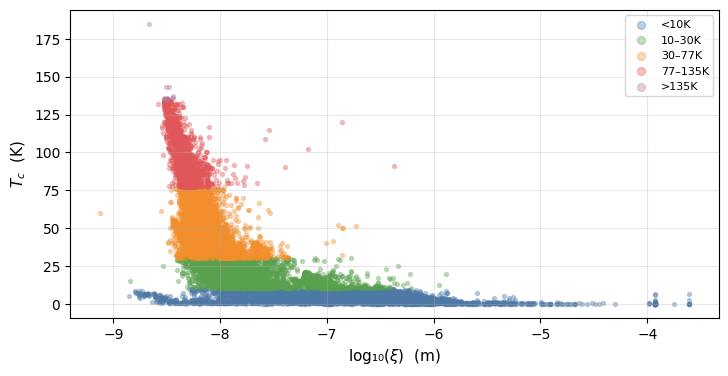


Saved: xi_vs_Tc.png
  Pearson (log): -0.8117  | Spearman: -0.8691


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, spearmanr

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('Final_dataset_83.csv')

tc  = df['critical_temp'].values
xi  = df['coherence_length'].values

# Log transforms (for visualization — raw values are too skewed)
log_xi  = np.log10(xi)
log_tc  = np.log10(np.clip(tc, 0.01, None))

# ── Correlation stats ──────────────────────────────────────────────────────
pr_xi,  _  = pearsonr(log_xi,  log_tc)
sr_xi,  _  = spearmanr(xi,     tc)

print("=" * 50)
print(f"  ξ  vs Tc  | Pearson (log): {pr_xi:.4f}  | Spearman: {sr_xi:.4f}")
print("=" * 50)

# ── Color by Tc bins for visual clarity ────────────────────────────────────
tc_bins   = [0, 10, 30, 77, 135, 999]
tc_labels = ['<10K', '10–30K', '30–77K', '77–135K', '>135K']
tc_colors = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759', '#b07aa1']
tc_cat    = pd.cut(tc, bins=tc_bins, labels=tc_labels)

# ── Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
# fig.suptitle('GL-Derived Features vs Critical Temperature (Tc)\nPhysics-Based Stacking Ensemble — Superconductivity Dataset',
#              fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.25, wspace=0.15)

# ── Plot 1: ξ vs Tc (log-log scatter) ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for lbl, col in zip(tc_labels, tc_colors):
    mask = tc_cat == lbl
    ax1.scatter(log_xi[mask], tc[mask],
                c=col, alpha=0.35, s=8, label=lbl, rasterized=True)

# Trend line
# z = np.polyfit(log_xi, tc, 1)
# xr = np.linspace(log_xi.min(), log_xi.max(), 200)
# ax1.plot(xr, np.polyval(z, xr), 'k--', lw=1.5, alpha=0.7, label='Trend')

ax1.set_xlabel('log₁₀($ξ$)  (m)', fontsize=11)
ax1.set_ylabel('$T_c$  (K)', fontsize=11)
# ax1.set_title(f'Coherence Length (ξ) vs Tc\nPearson(log): {pr_xi:.3f} | Spearman: {sr_xi:.3f}',
#               fontsize=11)
ax1.legend(fontsize=8, markerscale=2)
ax1.grid(True, alpha=0.3)

plt.savefig('xi_vs_Tc.png', dpi=600, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\nSaved: xi_vs_Tc.png")
print(f"  Pearson (log): {pr_xi:.4f}  | Spearman: {sr_xi:.4f}")


  Hc2 vs Tc | Pearson (log): 0.8117  | Spearman: 0.8691


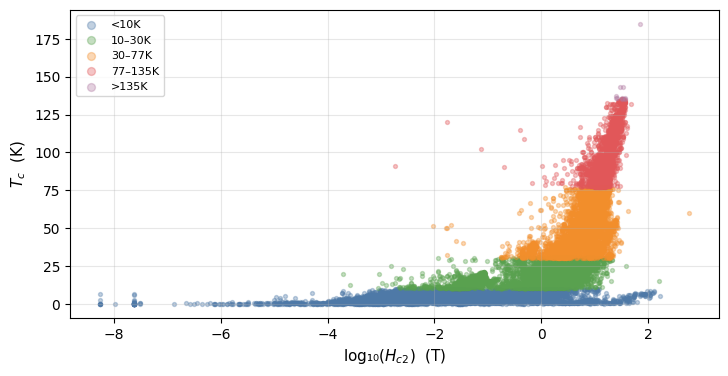


Saved: Hc2_vs_Tc.png
Pearson(log): 0.812 | Spearman: 0.869


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, spearmanr

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('Final_dataset_83.csv')

tc  = df['critical_temp'].values
hc2 = df['upper_critical_field'].values

# Log transforms (for visualization — raw values are too skewed)
log_hc2 = np.log10(hc2)
log_tc  = np.log10(np.clip(tc, 0.01, None))

# ── Correlation stats ──────────────────────────────────────────────────────
pr_hc2, _  = pearsonr(log_hc2, log_tc)
sr_hc2, _  = spearmanr(hc2,    tc)

print("=" * 50)
print(f"  Hc2 vs Tc | Pearson (log): {pr_hc2:.4f}  | Spearman: {sr_hc2:.4f}")
print("=" * 50)

# ── Color by Tc bins for visual clarity ────────────────────────────────────
tc_bins   = [0, 10, 30, 77, 135, 999]
tc_labels = ['<10K', '10–30K', '30–77K', '77–135K', '>135K']
tc_colors = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759', '#b07aa1']
tc_cat    = pd.cut(tc, bins=tc_bins, labels=tc_labels)

# ── Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
# fig.suptitle('GL-Derived Features vs Critical Temperature (Tc)\nPhysics-Based Stacking Ensemble — Superconductivity Dataset',
#  fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.25, wspace=0.15)

# ── Plot 2: Hc2 vs Tc (log-log scatter) ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for lbl, col in zip(tc_labels, tc_colors):
    mask = tc_cat == lbl
    ax2.scatter(log_hc2[mask], tc[mask],
                c=col, alpha=0.35, s=8, label=lbl, rasterized=True)

# z2 = np.polyfit(log_hc2, tc, 1)
# xr2 = np.linspace(log_hc2.min(), log_hc2.max(), 200)
# ax2.plot(xr2, np.polyval(z2, xr2), 'k--', lw=1.5, alpha=0.7, label='Trend')

ax2.set_xlabel('log₁₀($H_{c2}$)  (T)', fontsize=11)
ax2.set_ylabel('$T_c$  (K)', fontsize=11)
# ax2.set_title(f'Upper Critical Field (Hc2) vs Tc\nPearson(log): {pr_hc2:.3f} | Spearman: {sr_hc2:.3f}',
#               fontsize=11)
ax2.legend(fontsize=8, markerscale=2)
ax2.grid(True, alpha=0.3)

plt.savefig('Hc2_vs_Tc.png', dpi=600, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\nSaved: Hc2_vs_Tc.png")
print(f"Pearson(log): {pr_hc2:.3f} | Spearman: {sr_hc2:.3f}")

In [3]:

# ── Plot 3: ξ distribution by Tc bin (box plot) ───────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
data_xi = [log_xi[tc_cat == lbl] for lbl in tc_labels]
bp1 = ax3.boxplot(data_xi, patch_artist=True, notch=False,
                  medianprops=dict(color='black', lw=2))
for patch, col in zip(bp1['boxes'], tc_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax3.set_xticklabels(tc_labels, fontsize=9)
ax3.set_xlabel('Tc Range', fontsize=11)
ax3.set_ylabel('log₁₀(ξ)  [m]', fontsize=11)
ax3.set_title('ξ Distribution by Tc Range', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# ── Plot 4: Hc2 distribution by Tc bin (box plot) ─────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
data_hc2 = [log_hc2[tc_cat == lbl] for lbl in tc_labels]
bp2 = ax4.boxplot(data_hc2, patch_artist=True, notch=False,
                  medianprops=dict(color='black', lw=2))
for patch, col in zip(bp2['boxes'], tc_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax4.set_xticklabels(tc_labels, fontsize=9)
ax4.set_xlabel('Tc Range', fontsize=11)
ax4.set_ylabel('log₁₀(Hc2)  [T]', fontsize=11)
ax4.set_title('Hc2 Distribution by Tc Range', fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')


In [4]:

# ── Plot 5: ξ vs Hc2 (collinearity visual) ────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
sc = ax5.scatter(log_xi, log_hc2, c=tc, cmap='plasma',
                 alpha=0.3, s=6, rasterized=True)
cbar = plt.colorbar(sc, ax=ax5)
cbar.set_label('Tc [K]', fontsize=10)
ax5.set_xlabel('log₁₀(ξ)  [m]', fontsize=11)
ax5.set_ylabel('log₁₀(Hc2)  [T]', fontsize=11)
xi_hc2_corr, _ = pearsonr(log_xi, log_hc2)
ax5.set_title(f'ξ vs Hc2 — Collinearity Check\nPearson(log-log): {xi_hc2_corr:.4f}',
              fontsize=11)
ax5.grid(True, alpha=0.3)

# ── Plot 6: Tc histogram colored by family (context) ──────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.hist(tc, bins=60, color='#4e79a7', edgecolor='white',
         linewidth=0.4, alpha=0.85)
for cutoff, lbl, col in zip([10, 30, 77, 135],
                              ['10K', '30K', '77K\n(LN₂)', '135K'],
                              ['#59a14f','#f28e2b','#e15759','#b07aa1']):
    ax6.axvline(cutoff, color=col, lw=1.5, linestyle='--', alpha=0.8)
    ax6.text(cutoff+1, ax6.get_ylim()[1]*0.85, lbl,
             color=col, fontsize=8, va='top')
ax6.set_xlabel('Tc  [K]', fontsize=11)
ax6.set_ylabel('Count', fontsize=11)
ax6.set_title('Tc Distribution\n(21,263 samples)', fontsize=11)
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig('GL_features_vs_Tc.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\nSaved: GL_features_vs_Tc.png")

C:\Users\User\AppData\Local\Temp\ipykernel_18428\2818799798.py:5: UserWarning: Adding colorbar to a different Figure <Figure size 1800x1400 with 6 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(sc, ax=ax5)


<Figure size 640x480 with 0 Axes>


Saved: GL_features_vs_Tc.png


In [ ]:

# ── Step 5: Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'OOF SHAP Feature Importance — Fermi Velocity Model\n'
             f'(GroupKFold-5, {SHAP_MODEL}, n={len(df_759)} samples)',
             fontsize=13, fontweight='bold')

# Left: top 20 bar chart
top_plot = oof_shap_importance.head(TOP_N)
colors   = ['#2ecc71' if f in selected_numeric else '#e74c3c'
            for f in top_plot.index]
axes[0].barh(range(len(top_plot)), top_plot.values[::-1],
             color=colors[::-1], edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(top_plot)))
axes[0].set_yticklabels(top_plot.index[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP| on held-out folds', fontsize=10)
axes[0].set_title(f'Top {TOP_N} Features (OOF SHAP)', fontsize=11)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3, axis='x')

# Right: cumulative importance curve
cumulative = np.cumsum(oof_shap_importance.values) / total_importance * 100
axes[1].plot(range(1, len(cumulative)+1), cumulative,
             color='#3498db', linewidth=2, marker='o', markersize=3)
axes[1].axvline(TOP_N, color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Selected: top {TOP_N}')
axes[1].axhline(cumulative[TOP_N-1], color='#e74c3c', linestyle=':', linewidth=1,
                label=f'{cumulative[TOP_N-1]:.1f}% importance captured')
axes[1].fill_between(range(1, TOP_N+1), cumulative[:TOP_N],
                     alpha=0.15, color='#2ecc71')
axes[1].set_xlabel('Number of features', fontsize=10)
axes[1].set_ylabel('Cumulative importance (%)', fontsize=10)
axes[1].set_title('Cumulative SHAP Importance', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(1, len(oof_shap_importance))
axes[1].set_ylim(0, 101)

plt.tight_layout()
plt.savefig('shap_oof_importance.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("\nSaved: shap_oof_importance.png")

# ── Step 6: UPDATE numeric_features for downstream steps ─────────────────────
# This overwrites the variable defined in STEP 5
# All subsequent steps (STEP 6 preprocessor, STEP 7 training) will use
# selected_numeric automatically
numeric_features = selected_numeric   # ← downstream steps use this

print(f"\n  numeric_features updated: {len(numeric_features)} features")
print(f"  categorical_features unchanged: {categorical_features}")
print(f"\n  X_train will now use: {len(numeric_features)} numeric "
      f"+ {len(categorical_features)} categorical features")
print("=" * 60)
print("  STEP 5B complete — proceed to STEP 6")
print("=" * 60)